In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools
import pickle
import mdtraj as md
from itertools import islice
from math import nan, isnan
from itertools import combinations
from sklearn.preprocessing import normalize
from numpy import linalg as eig
from collections import OrderedDict, Counter
from matplotlib.backends.backend_pdf import PdfPages
from numpy import random
import signal
import matplotlib.ticker as ticker


In [2]:

file_com = open('/Users/adelielouet/Documents/science/dd_proj/hotspots_oji_overlap/save_pckl/d_24_t_com_avg.pkl','rb')
distances_com = pickle.load(file_com)
#### The fomat of distances [DistA1,DistB1..],[DistA2,DistB2..]... so its [42distces]*numts
file_com.close()


## This is using the smallest distance
distances=[]
file_closest = open('/Users/adelielouet/Documents/science/dd_proj/hotspots_oji_overlap/save_pckl/d_24_t_closest.pkl','rb')
distances_closest = pickle.load(file_closest)
file_closest.close()



In [3]:

w_com=0.9
w_closest=0.1

distances_combined = (w_com * np.array(distances_com)) + (w_closest * np.array(distances_closest))

distance_threshold_combined = (0.75*w_com)+(0.45*w_closest)

distances=distances_combined

number_contact=[]
for ts, values in enumerate(distances):
    number_contact.append(sum(1 for x in values if x <= distance_threshold_combined))

print(f"Average number of contacts between c alpha and ligand com is {np.mean(number_contact)}")


Average number of contacts between c alpha and ligand com is 3.2034295352323836


In [4]:

### This is where you decide the -uplet type
#uplet_type=2
uplet_types=list(range(2,6))


w_com/w_closest ratio is 0.9 /0.1 and using 2000 transition matrix size
For 2, there are 847 unique pairs
For 2, there were 226429 transitions, but now filtered there are 226429
w_com/w_closest ratio is 0.9 /0.1 and using 2000 transition matrix size
For 3, there are 5834 unique pairs
For 3, there were 168964 transitions, but now filtered there are 150392
w_com/w_closest ratio is 0.9 /0.1 and using 2000 transition matrix size
For 4, there are 10280 unique pairs
For 4, there were 99689 transitions, but now filtered there are 77578
w_com/w_closest ratio is 0.9 /0.1 and using 2000 transition matrix size
For 5, there are 7960 unique pairs
For 5, there were 47977 transitions, but now filtered there are 38439


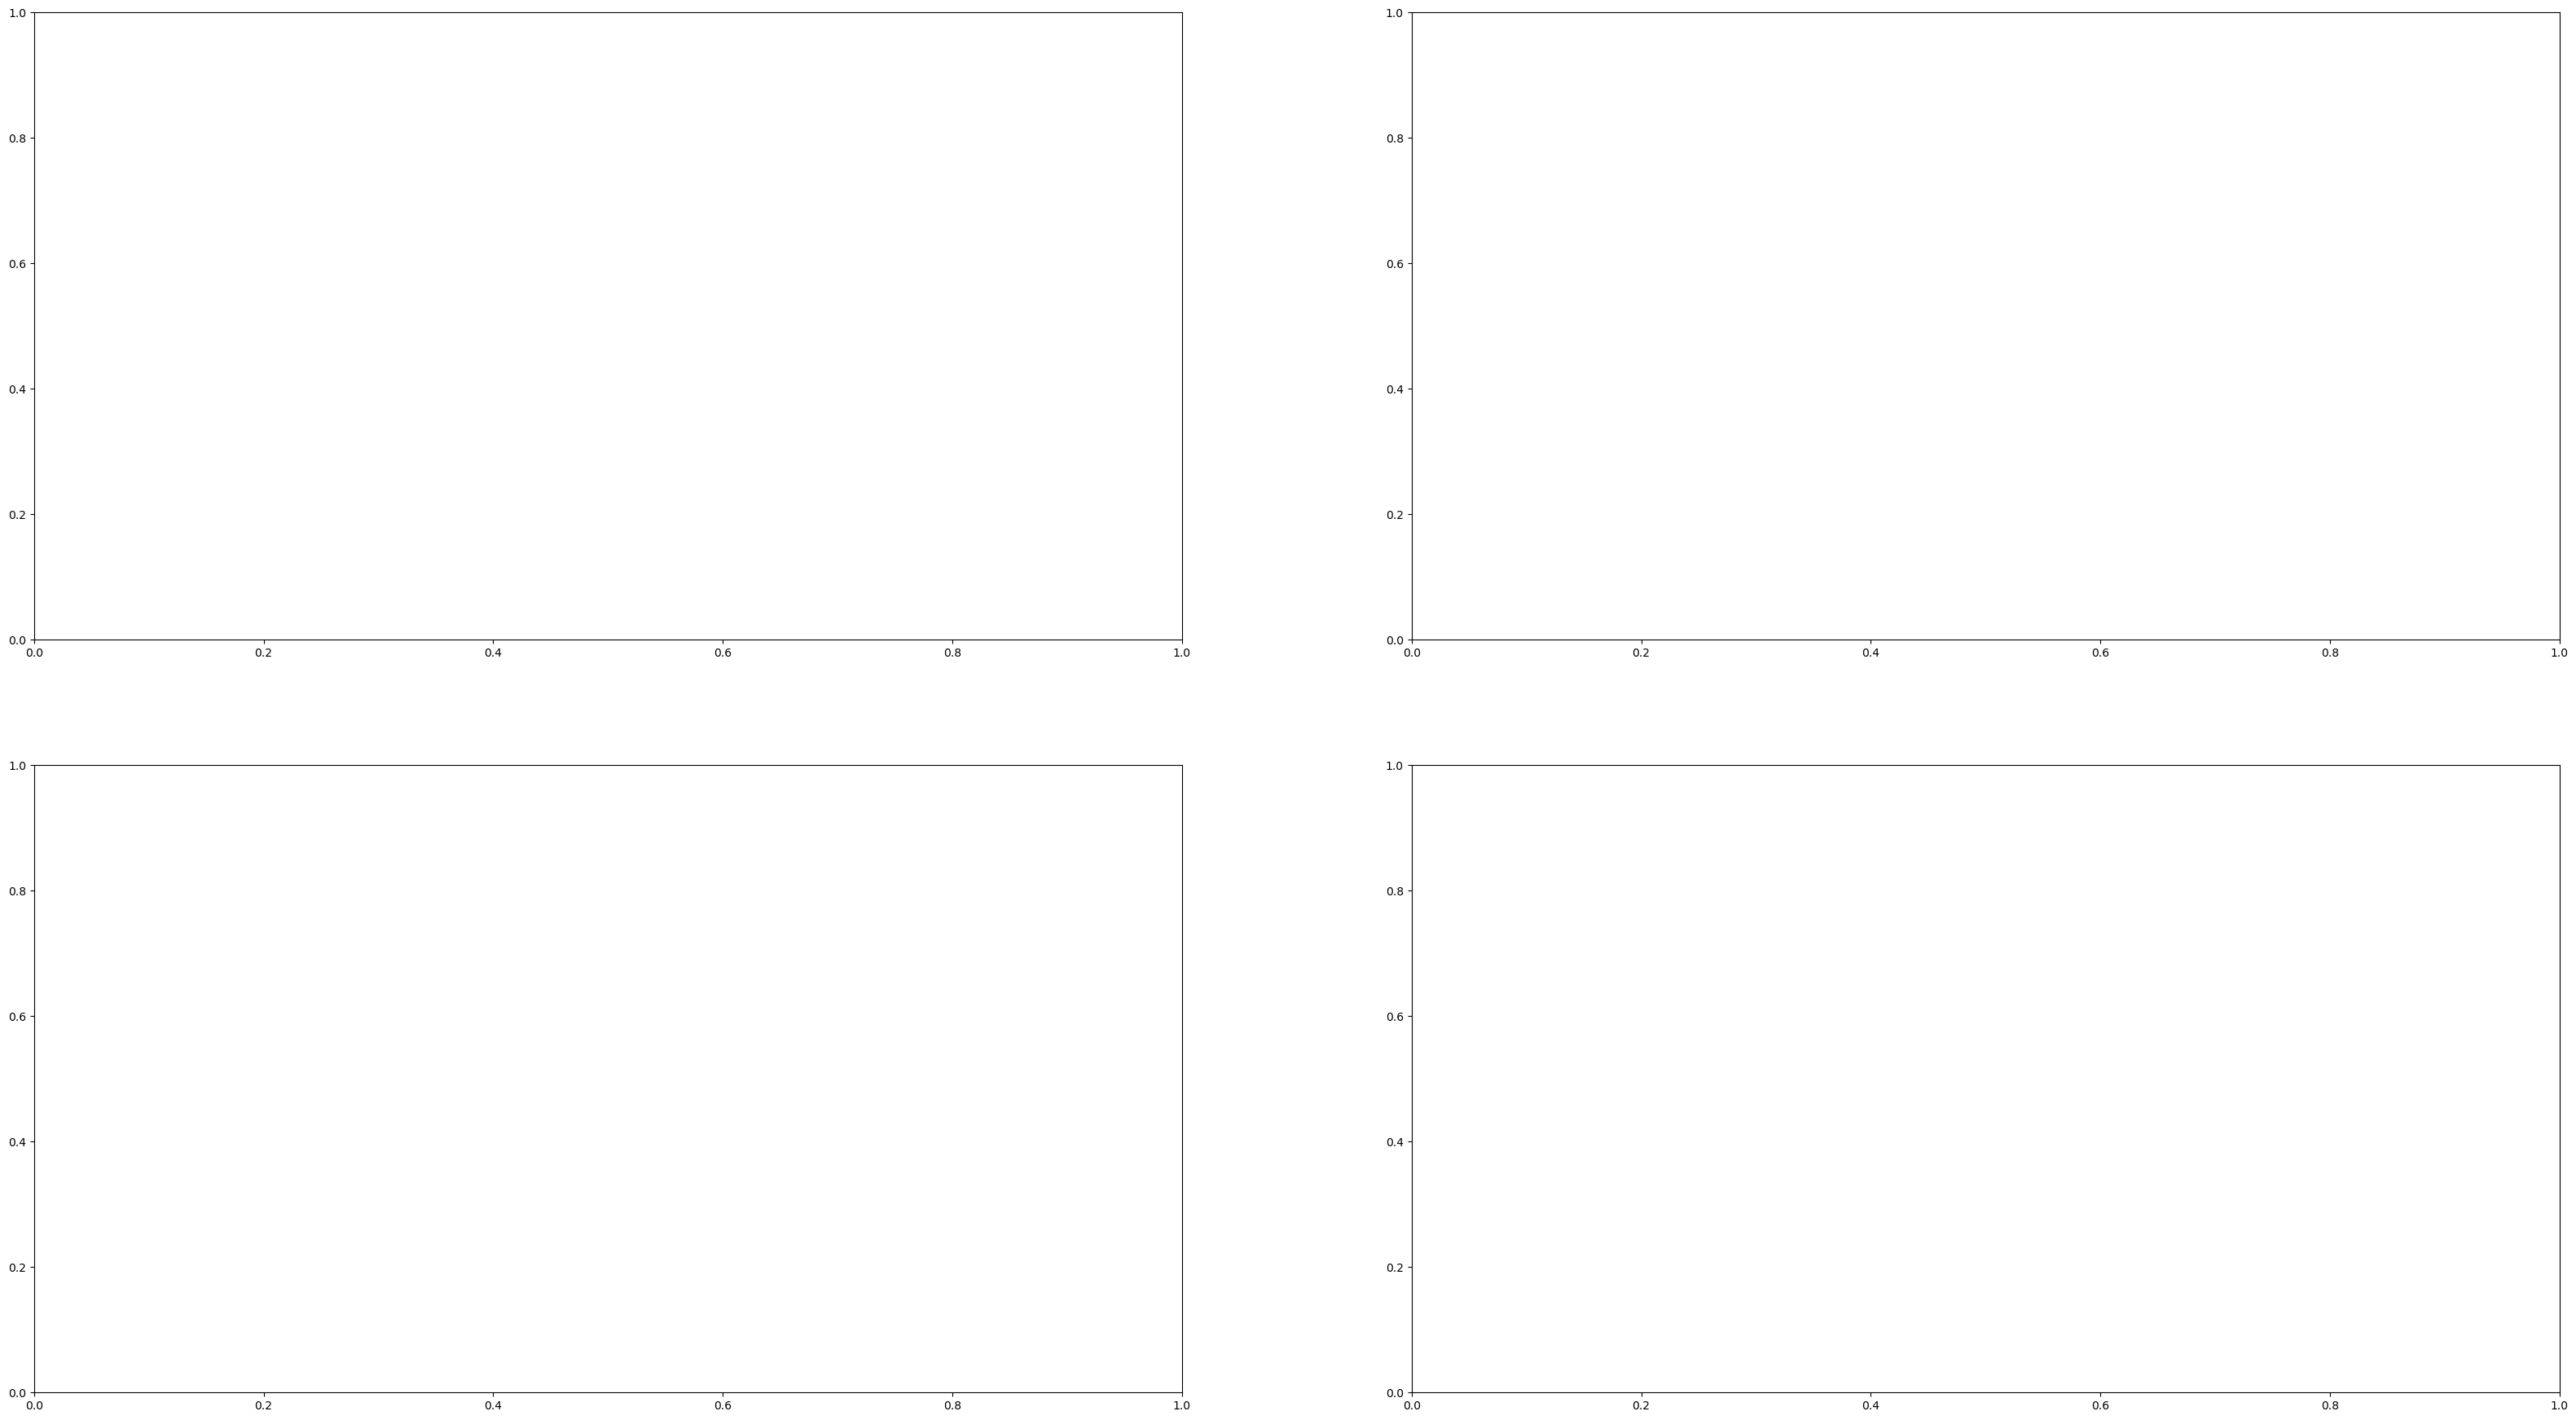

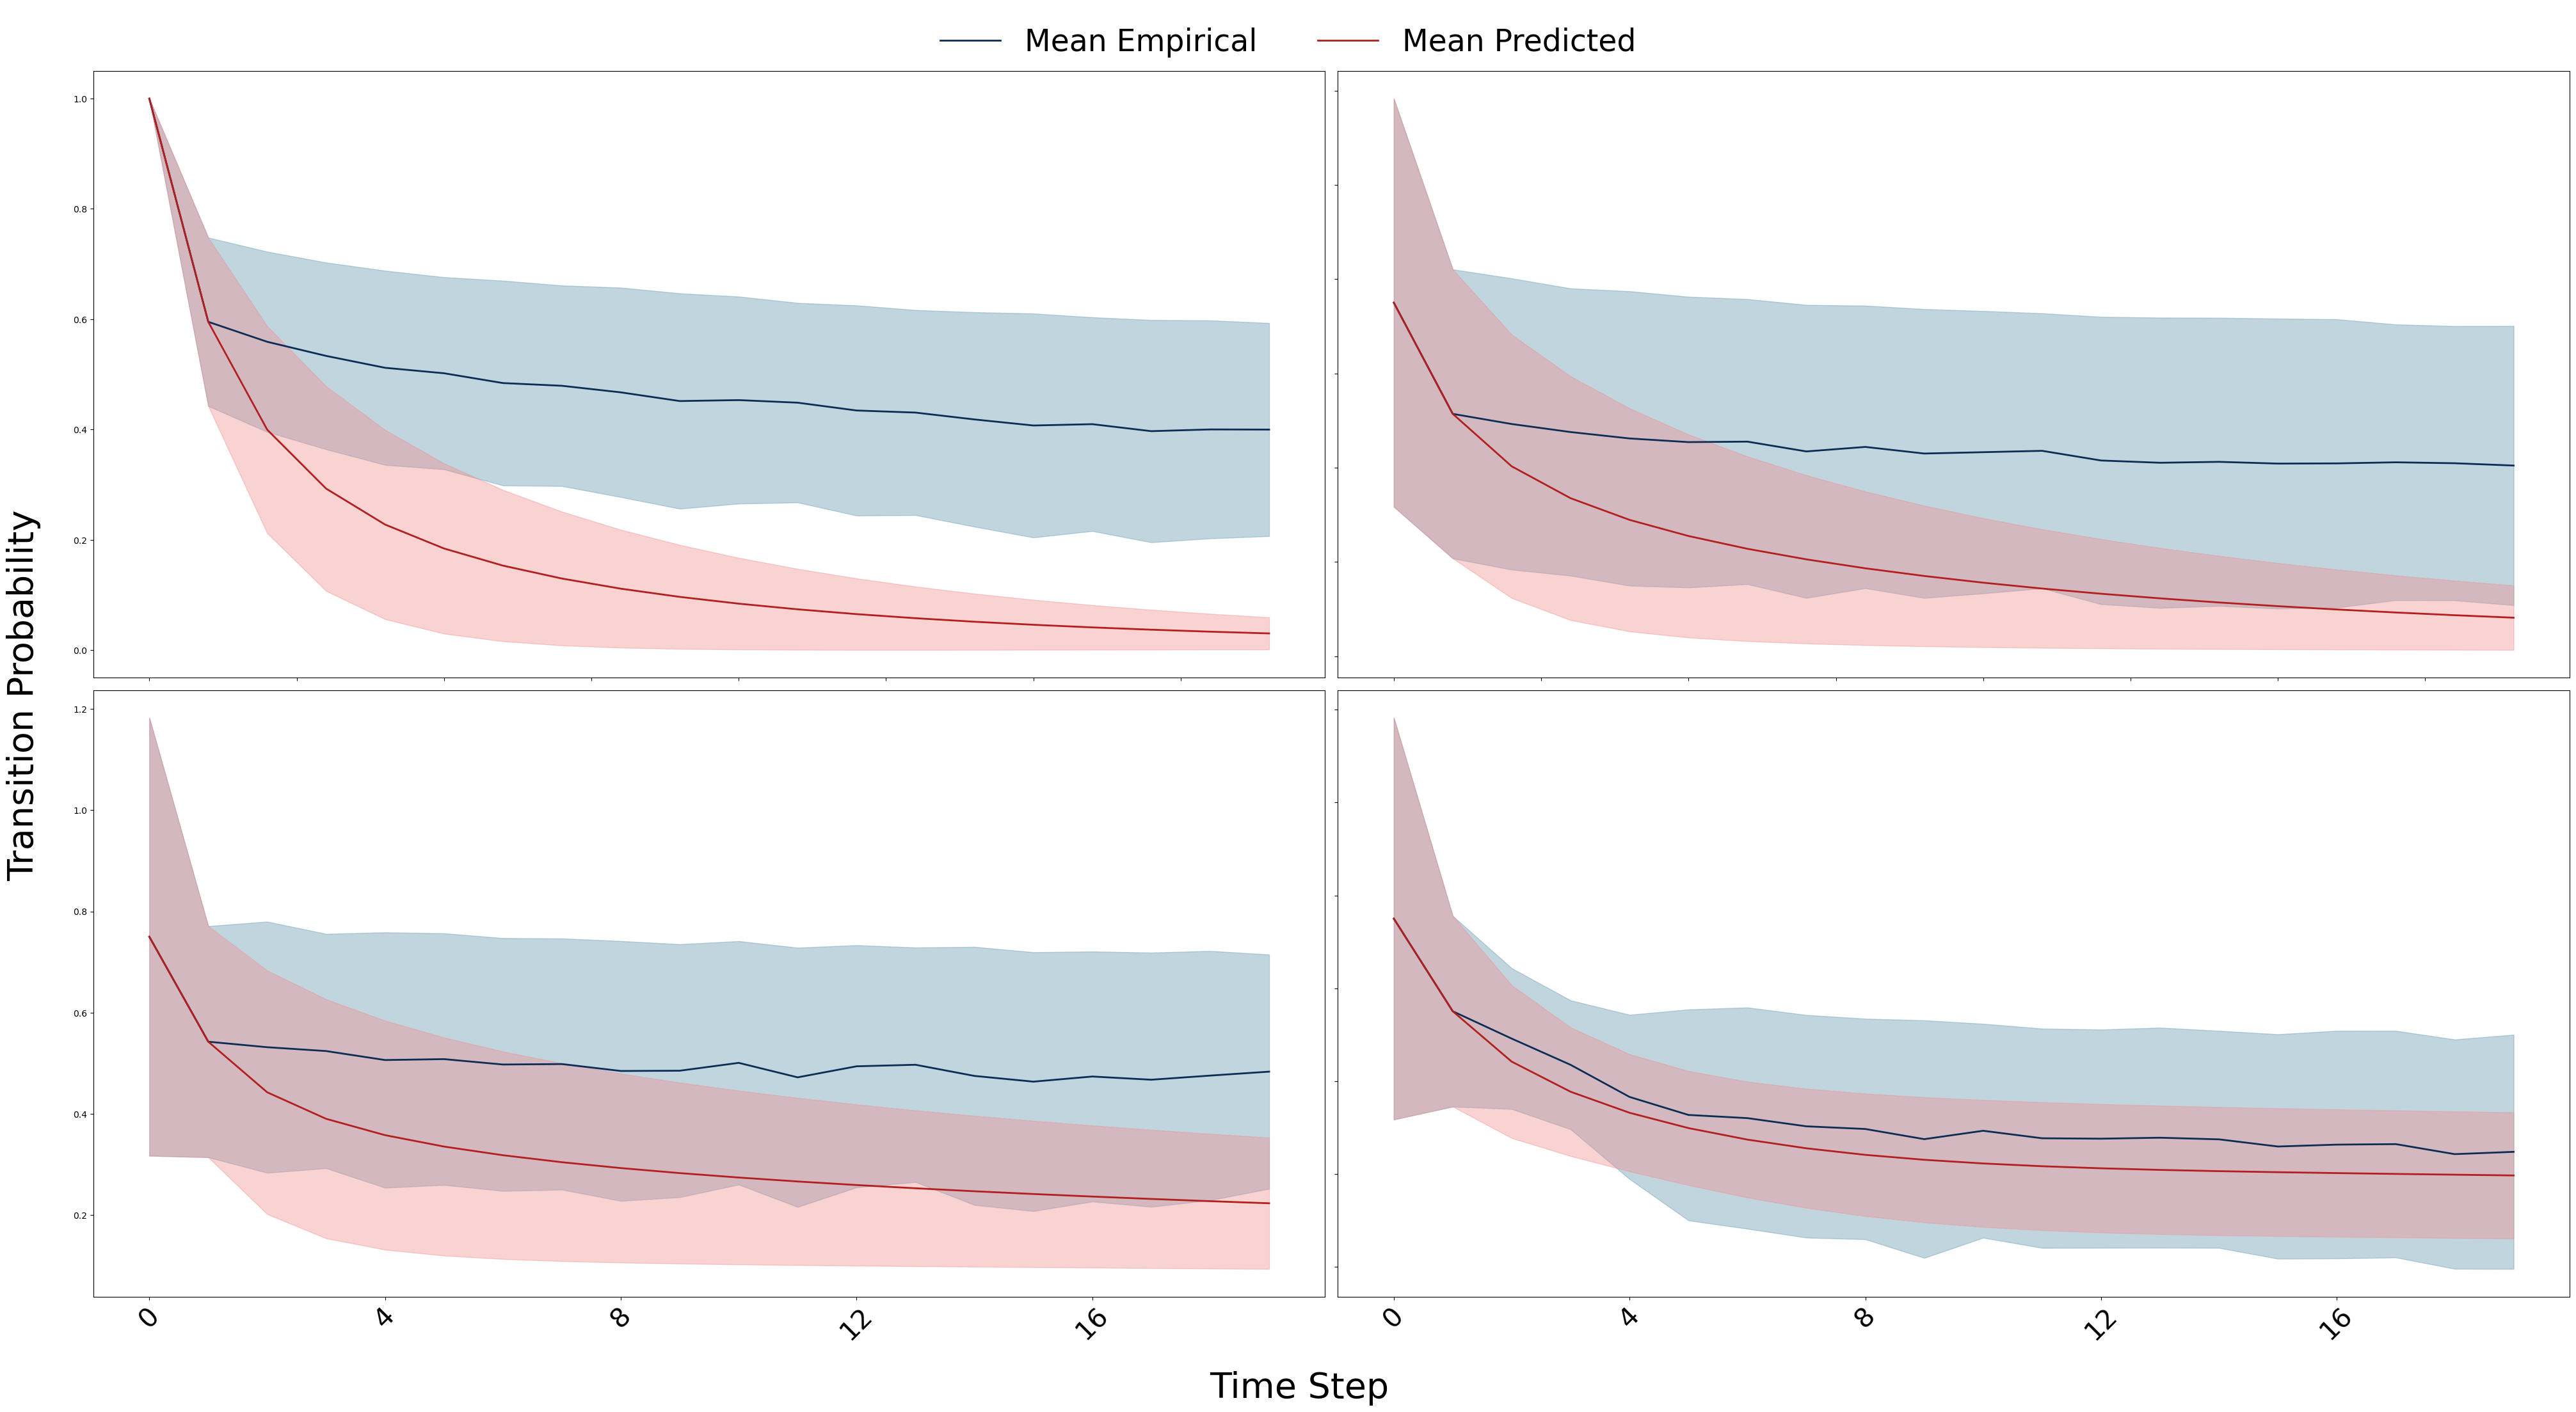

In [ ]:
n_cols = 2
n_rows = int(len(uplet_types)/n_cols)
axes = axes.flatten()  # Flatten for easier indexing

transiton_cutoff=2000

sample_size=12 #12/2

blues = ['#b3cde0', '#6497b1', '#1f4579', '#0b2c55']  # Lighter to darker blues
reds = ['#f7b7b7', '#f08f8f', '#d94e4e', '#b31f1f']  # Lighter to darker reds

# Setting up figure size and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20 * n_cols, 22))
axes = axes.flatten()

for idx,uplet_type in enumerate(uplet_types):
    print(f'w_com/w_closest ratio is {w_com} /{w_closest} and using {transiton_cutoff} transition matrix size')
    # Initialize a dictionary to store counts of simultaneous contacts for each residue pair
    residue_pairs = list(combinations(range(42), uplet_type))  # all unique pairs of residues
    contact_counts_top_uplet_type_indices = {pair: 0 for pair in residue_pairs}

    num_timesteps = distances.shape[0]
    contact_counts_uplet_type_timesteps=[]

    for t in range(num_timesteps):
        close_residues = np.where(distances[t, :] < distance_threshold_combined)[0]
        close_residues_values = [x for x in distances[t] if x < distance_threshold_combined]

        paired = list(zip(close_residues_values, close_residues))
        sorted_pairs = sorted(paired, key=lambda x: x[0])
        top_uplet_type_indices = [pair[1] for pair in sorted_pairs[:uplet_type]]
    # print(close_residues)

        if len(top_uplet_type_indices) == uplet_type:
            contact_counts_uplet_type_timesteps.append(top_uplet_type_indices)


    #this sorts the values of sublists in order so that we don't have any repeats ([6,3,9) =[3,6,9]]) 
    unique_uplets_pre_process=[sorted(sublist) for sublist in contact_counts_uplet_type_timesteps]

    frequency = Counter(tuple(sorted(sublist)) for sublist in unique_uplets_pre_process)
    print(f'For {uplet_type}, there are {len(frequency)} unique pairs')

    #removes all uplets that are less than 100 in frequency
    #filtered_keys = [key for key, count in frequency.items() if count > 50] 

    #keeps top 1000 uplets
    filtered_keys = [item for item, count in frequency.most_common(transiton_cutoff)]

    #helps to transorm the sublists into usable format
    data_preprocessed = [tuple(x) for x in unique_uplets_pre_process]

    #removes all sublists that arent present in filtered_keys (eg- any sublist/uplet type that hasnt occured X times)
    data = [sublist for sublist in data_preprocessed if sublist in filtered_keys]
    
    print(f'For {uplet_type}, there were {len(data_preprocessed)} transitions, but now filtered there are {len(data)}')

    transition_matrix = np.zeros((len(filtered_keys), len(filtered_keys)), dtype=int)

    value_to_index =  {tuple(row): index for index, row in enumerate(filtered_keys)}


    for i in range(len(data) - 1):
        current_value = data[i]
        next_value = data[i + 1]
        
        sorted_current_value = tuple(sorted(current_value))
        sorted_next_value = tuple(sorted(next_value))
        
        transition_matrix[value_to_index[sorted_current_value], value_to_index[sorted_next_value]] += 1

    x_normed = normalize(transition_matrix, axis=1, norm='l1')

    flat_indices = np.unravel_index(
        np.argpartition(-transition_matrix.ravel(), len(transition_matrix))[:len(transition_matrix)],
        transition_matrix.shape
    )

    top_indices_values = [
        ((i, j), transition_matrix[i, j]) 
        for i, j in zip(flat_indices[0], flat_indices[1])]
    
    top_indices_values_sorted=sorted(top_indices_values, key=lambda x: x[1],reverse=True)  

    #now to look at radnom samples:
    int_sample_from=[random.randint(0, len(value_to_index) - 1) for x in range(2)]


    all_empirical_values = []
    all_predicted_values = []

    for state_number in (list(range(0, 2)) + int_sample_from):
        index_1 = top_indices_values_sorted[state_number][0][0]
        index_2 = top_indices_values_sorted[state_number][0][1]
        transition_quantity = top_indices_values_sorted[state_number][1]

        start_state = list(list(value_to_index.keys())[index_1])
        end_state = list(list(value_to_index.keys())[index_2])

        #print(f"Run {idx + 1}: Start State: {start_state}, End State: {end_state}")

        time_steps = np.arange(0, 20)
        empirical_values = []
        predicted_values = []

        for tau in time_steps:
            # Calculate theoretical n-step transition matrix
            theoretical_n_step_matrix = np.linalg.matrix_power(x_normed, tau)

            sorted_start_state_index = value_to_index[tuple(sorted(start_state))]
            sorted_end_state_index = value_to_index[tuple(sorted(end_state))]

            theoretical_prob = theoretical_n_step_matrix[sorted_start_state_index, sorted_end_state_index]

            # Calculate empirical n-step transition matrix
            num_states = transition_matrix.shape[0]
            empirical_n_step_matrix = np.zeros((num_states, num_states), dtype=float)

            for i in range(len(data) - tau):
                current_value = tuple(sorted(data[i]))
                next_value = tuple(sorted(data[i + tau]))

                current_index = value_to_index[current_value]
                next_index = value_to_index[next_value]

                empirical_n_step_matrix[current_index, next_index] += 1
                
            empirical_n_step_matrix = normalize(empirical_n_step_matrix, axis=1, norm='l1')
            empirical_prob = empirical_n_step_matrix[sorted_start_state_index, sorted_end_state_index]

            empirical_values.append(empirical_prob)
            predicted_values.append(theoretical_prob)

        all_empirical_values.append(empirical_values)
        all_predicted_values.append(predicted_values)

    mean_empirical = np.mean(all_empirical_values, axis=0)
    std_empirical = np.std(all_empirical_values, axis=0)

    mean_predicted = np.mean(all_predicted_values, axis=0)
    std_predicted = np.std(all_predicted_values, axis=0)

    ax = axes[idx]
    
    ax.plot(time_steps, mean_empirical, label='Mean Empirical', color=blues[3], lw=2)

    ax.fill_between(time_steps, mean_empirical - std_empirical, mean_empirical + std_empirical,
                    color=blues[1], alpha=0.4)
    ax.plot(time_steps, mean_predicted, label='Mean Predicted', color=reds[3], lw=2)

    ax.fill_between(time_steps, mean_predicted - std_predicted, mean_predicted + std_predicted,
                    color=reds[1], alpha=0.4)

    if idx >= (n_rows - 1) * n_cols:
        ax.set_xticks(time_steps)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
        ax.tick_params(axis='x', labelrotation=45, labelsize=30)

    else:
        ax.tick_params(axis='x', labelbottom=False)

    # Y ticks only on left column
    if idx % n_cols != 0:
        ax.tick_params(axis='y', labelleft=False,labelsize=35)

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=34, frameon=False)

fig.supylabel("Transition Probability", fontsize=40, x=-.005)
fig.supxlabel("Time Step", fontsize=40,y=-.005)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leaves space at top for the legend
plt.show()
